<a href="https://colab.research.google.com/github/Ananya943/Ananya943/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================
# STEP 1: Import Libraries
# ==============================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Model evaluation
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Neural Network (Deep Learning)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
!pip install tensorflow

Load Dataset

In [ ]:
# ==============================
# STEP 2: Load Dataset
# ==============================

# Load the dataset
df = pd.read_csv("telco_churn.csv")

# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df_original = df.copy()

Check Dataset Structure

In [ ]:
# Shape of dataset (rows, columns)
df.shape

(7043, 21)

In [ ]:
# Column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# Data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Check Missing Values

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Encode Binary Columns (Yes/No, Male/Female)

In [ ]:
# ==============================
# STEP 4: Encoding
# ==============================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Identify binary categorical columns
binary_cols = df.columns[df.nunique() == 2]

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

One-Hot Encode Remaining Categorical Columns

In [ ]:
# Apply one-hot encoding
df = pd.get_dummies(df, drop_first=True)

Check Result

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,customerID_0003-MKNFE,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,0,1,0,1,0,1,29.85,0,False,...,False,False,False,False,False,False,False,False,False,False
1,1,0,0,0,34,1,0,56.95,0,False,...,False,False,False,False,False,False,False,False,False,False
2,1,0,0,0,2,1,1,53.85,1,False,...,False,False,False,False,False,False,False,False,False,False
3,1,0,0,0,45,0,0,42.30,0,False,...,False,False,False,False,False,False,False,False,False,False
4,0,0,0,0,2,1,1,70.70,1,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 13602 entries, gender to TotalCharges_999.9
dtypes: bool(13593), float64(1), int64(8)
memory usage: 91.8 MB


Encode Binary Columns Properly

In [ ]:
# ==============================
# STEP 4: Encoding
# ==============================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Select only object (categorical) columns
cat_cols = df.select_dtypes(include=['object']).columns

# Encode binary categorical columns (only 2 unique values)
for col in cat_cols:
    if df[col].nunique() == 2:
        df[col] = le.fit_transform(df[col])

One-Hot Encode Remaining Columns

In [ ]:
# One-hot encoding for multi-category columns
df = pd.get_dummies(df, drop_first=True)

Verify Encoding

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,customerID_0003-MKNFE,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,0,1,0,1,0,1,29.85,0,False,...,False,False,False,False,False,False,False,False,False,False
1,1,0,0,0,34,1,0,56.95,0,False,...,False,False,False,False,False,False,False,False,False,False
2,1,0,0,0,2,1,1,53.85,1,False,...,False,False,False,False,False,False,False,False,False,False
3,1,0,0,0,45,0,0,42.30,0,False,...,False,False,False,False,False,False,False,False,False,False
4,0,0,0,0,2,1,1,70.70,1,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 13602 entries, gender to TotalCharges_999.9
dtypes: bool(13593), float64(1), int64(8)
memory usage: 91.8 MB


In [ ]:
df.select_dtypes(include=['object']).columns

Index([], dtype='object')

In [ ]:
df.columns[-1]

'TotalCharges_999.9'

Exploratory Data Analysis (EDA)

Churn Distribution

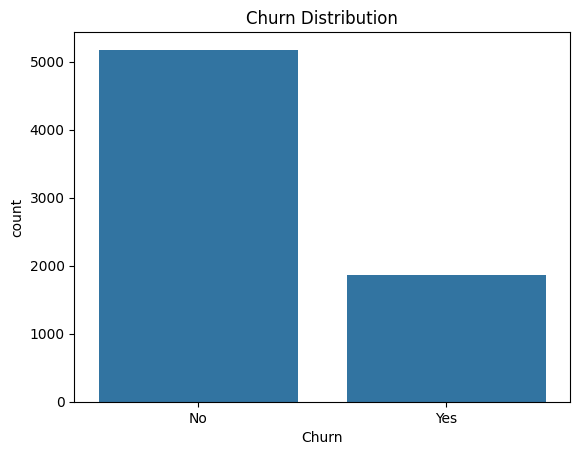

,proportion
Churn,
No,73.463013
Yes,26.536987


In [ ]:
sns.countplot(x='Churn', data=df_original)
plt.title("Churn Distribution")
plt.show()

df_original['Churn'].value_counts(normalize=True) * 100

Tenure vs Churn

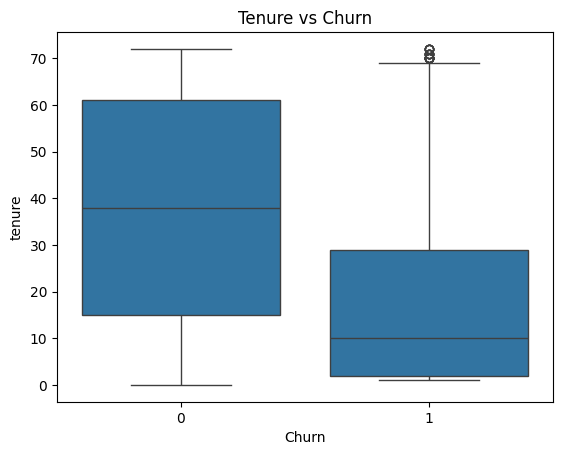

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

Monthly Charges vs Churn

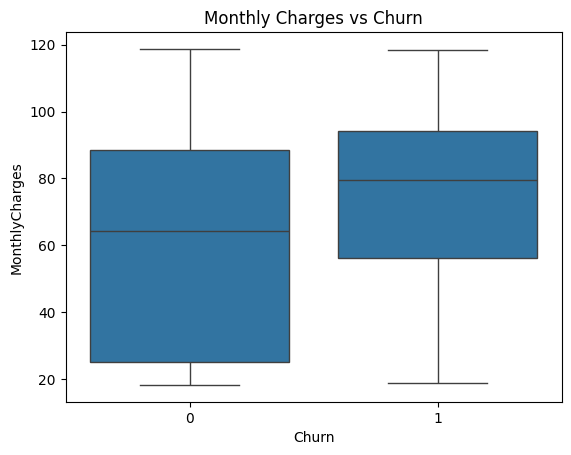

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Contract Type vs Churn

In [ ]:
# If Contract was one-hot encoded, check columns
contract_cols = [col for col in df.columns if "Contract" in col]

df.groupby(contract_cols)['Churn'].mean()

Contract_One year  Contract_Two year
False              False                0.427097
                   True                 0.028319
True               False                0.112695
Name: Churn, dtype: float64

Correlation Heatmap

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()